# 03. Baseline Forecasting & Rolling-Origin Evaluation

**Project:** Fodripio - Forecast-Driven Production Planning and Inventory Optimization Under Uncertain Demand  
**Phase:** Phase 2 — Forecasting Baselines  

## Objectives
1. Fit and evaluate all 6 baseline forecasting models (`Naive`, `SeasonalNaive`, `MovingAverage_7`, `MovingAverage_14`, `ExponentialSmoothing`, `SARIMAX`).
2. Execute multi-origin receding horizon evaluation using `RollingOriginValidator` (4 origins, $H=14$ days).
3. Aggregate performance metrics (`WAPE`, `MAE`, `RMSE`, `sMAPE`, `MASE`) using `ForecastEvaluator`.
4. Establish official baseline performance benchmarks for Phase 3 ML forecasters.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.data.load import DataLoader
from src.forecasting.baselines import (
    NaiveForecaster,
    SeasonalNaiveForecaster,
    MovingAverageForecaster,
    ExponentialSmoothingForecaster,
    SARIMAForecaster,
)
from src.evaluation.validation import RollingOriginValidator
from src.evaluation.metrics import ForecastEvaluator

plt.style.use('seaborn-v0_8-whitegrid')
print("Environment and models ready.")

Environment and models ready.


## 1. Load Processed Demand Data

In [3]:
data_path = os.path.join(project_root, 'data', 'processed', 'demand_processed.csv')
loader = DataLoader(data_path)
df = loader.load_raw_data()
loader.process()
print("Data summary:", loader.summarize())

2026-10-02 16:55:31,969 - INFO - Loading raw demand data from C:\zendvalmics\project\fodripio\data\processed\demand_processed.csv
2026-10-02 16:55:31,984 - INFO - Loaded 3655 rows spanning 2024-01-01 00:00:00 to 2025-12-31 00:00:00
2026-10-02 16:55:32,036 - INFO - Outlier flagging complete. Total outliers flagged: 8
2026-10-02 16:55:32,037 - INFO -   Product P1: 4 outliers (0.5%)
2026-10-02 16:55:32,038 - INFO -   Product P2: 1 outliers (0.1%)
2026-10-02 16:55:32,038 - INFO -   Product P3: 2 outliers (0.3%)
2026-10-02 16:55:32,039 - INFO -   Product P4: 0 outliers (0.0%)
2026-10-02 16:55:32,042 - INFO -   Product P5: 1 outliers (0.1%)


Data summary: {'num_rows': 3655, 'num_products': 5, 'min_date': '2024-01-01', 'max_date': '2025-12-31', 'total_demand': 331658.29000000004, 'avg_daily_demand': 90.74098221614229, 'total_outliers': 8}


## 2. Execute Rolling-Origin Validation Framework

In [4]:
validator = RollingOriginValidator()
evaluator = ForecastEvaluator()

models = {
    "Naive (Last Value)": NaiveForecaster(),
    "Seasonal Naive (Lag-7)": SeasonalNaiveForecaster(seasonal_period=7),
    "Moving Average (W=7)": MovingAverageForecaster(window=7),
    "Moving Average (W=14)": MovingAverageForecaster(window=14),
    "Exponential Smoothing (ETS)": ExponentialSmoothingForecaster(seasonal_periods=7),
    "SARIMA (1,1,1)x(1,1,1)7": SARIMAForecaster(order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)),
}

horizon = 14
step_size = 14
num_origins = 4

overall_results = []
model_eval_dfs = {}

for name, model in models.items():
    print(f"Evaluating {name}...")
    eval_df = validator.evaluate(
        df=df,
        forecaster=model,
        horizon=horizon,
        step_size=step_size,
        num_origins=num_origins,
        min_train_days=60,
    )
    model_eval_dfs[name] = eval_df
    
    metrics = evaluator.evaluate_overall(eval_df, in_sample_df=df)
    metrics["Model"] = name
    overall_results.append(metrics)

summary_df = pd.DataFrame(overall_results)[["Model", "WAPE", "MAE", "RMSE", "sMAPE", "MASE"]].sort_values("WAPE").reset_index(drop=True)
summary_df

Evaluating Naive (Last Value)...
Evaluating Seasonal Naive (Lag-7)...
Evaluating Moving Average (W=7)...
Evaluating Moving Average (W=14)...
Evaluating Exponential Smoothing (ETS)...
Evaluating SARIMA (1,1,1)x(1,1,1)7...


,Model,WAPE,MAE,RMSE,sMAPE,MASE
0,"SARIMA (1,1,1)x(1,1,1)7",16.98,12.7987,19.3063,16.99,0.1706
1,Exponential Smoothing (ETS),17.00,12.8125,19.2187,18.20,0.1708
2,Seasonal Naive (Lag-7),18.70,14.0955,20.8787,18.68,0.1879
3,Moving Average (W=14),26.15,19.7096,26.7457,28.01,0.2627
4,Moving Average (W=7),26.27,19.7957,26.5200,28.13,0.2639
5,Naive (Last Value),34.75,26.1880,35.1438,35.63,0.3491


## 3. Overall Baseline Benchmark Comparison

C:\Users\hp\AppData\Local\Temp\ipykernel_15976\3106507061.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='WAPE', y='Model', palette='Blues_r', ax=ax)


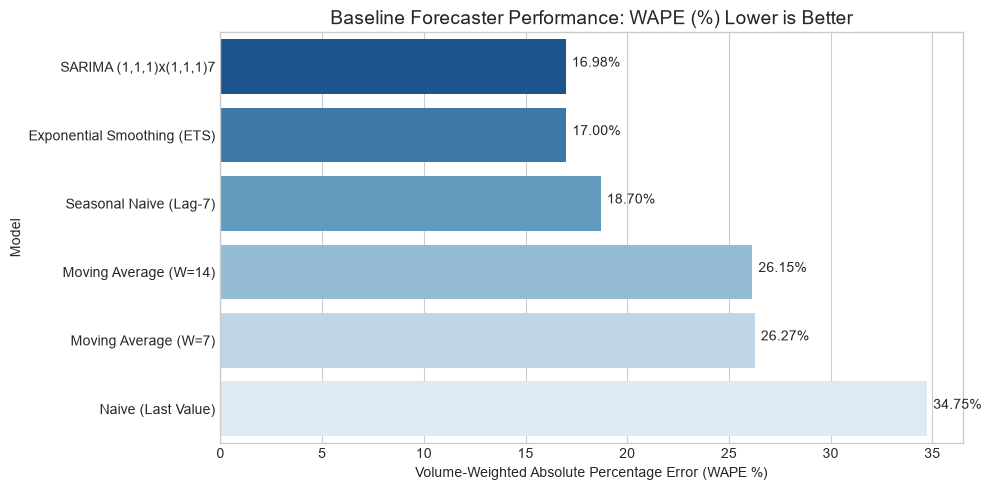

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=summary_df, x='WAPE', y='Model', palette='Blues_r', ax=ax)
ax.set_title("Baseline Forecaster Performance: WAPE (%) Lower is Better", fontsize=14)
ax.set_xlabel("Volume-Weighted Absolute Percentage Error (WAPE %)")
for i, v in enumerate(summary_df['WAPE']):
    ax.text(v + 0.3, i, f"{v:.2f}%")
plt.tight_layout()
plt.show()

## 4. Per-Product Performance Breakdown

In [16]:
best_model_name = summary_df.iloc[0]['Model']
print(f"Per-Product Metric Breakdown for Best Model ({best_model_name}):")
best_eval_df = model_eval_dfs[best_model_name]
prod_metrics = evaluator.evaluate_by_product(best_eval_df, in_sample_df=df)
prod_metrics

Per-Product Metric Breakdown for Best Model (SARIMA (1,1,1)x(1,1,1)7):


,product_id,WAPE,MAE,RMSE,sMAPE,MASE
0,P1,16.50,16.3778,21.8012,16.24,0.6248
1,P2,12.07,7.7941,10.2972,12.80,0.5088
2,P3,18.60,26.6602,33.3494,19.71,0.6815
3,P4,19.97,9.4212,12.1418,19.76,0.9373
4,P5,16.67,3.7403,4.7674,16.46,0.6492


## 5. Forecast Trajectory vs. Actual Demand Visualizations

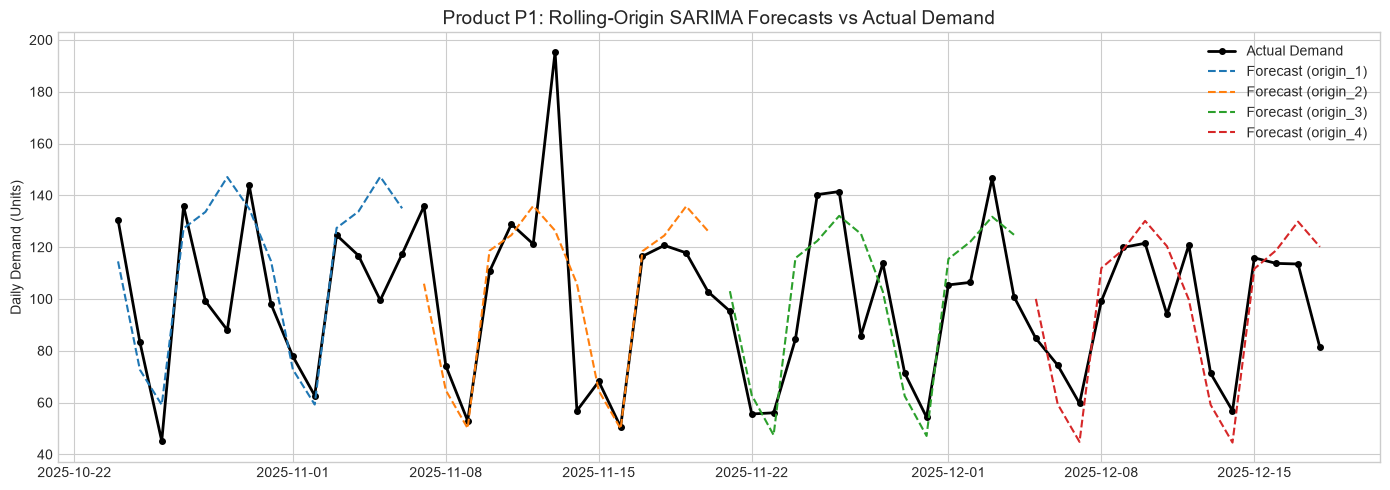

In [17]:
p_sub = best_eval_df[best_eval_df['product_id'] == 'P1'].sort_values('date')
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(p_sub['date'], p_sub['actual'], label='Actual Demand', color='black', linewidth=2, marker='o', markersize=4)
for orig_id, orig_df in p_sub.groupby('origin_id'):
    ax.plot(orig_df['date'], orig_df['forecast'], '--', label=f'Forecast ({orig_id})')
ax.set_title("Product P1: Rolling-Origin SARIMA Forecasts vs Actual Demand", fontsize=14)
ax.set_ylabel("Daily Demand (Units)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 6. Error Progression Over Horizon Steps ($h=1 \dots 14$)

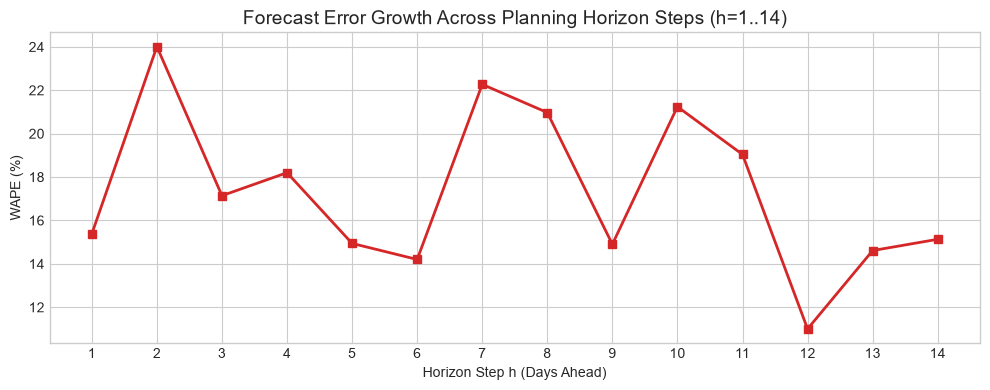

In [18]:
horizon_metrics = evaluator.evaluate_by_horizon(best_eval_df)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(horizon_metrics['horizon_step'], horizon_metrics['WAPE'], marker='s', color='tab:red', linewidth=2)
ax.set_title("Forecast Error Growth Across Planning Horizon Steps (h=1..14)", fontsize=14)
ax.set_xlabel("Horizon Step h (Days Ahead)")
ax.set_ylabel("WAPE (%)")
ax.set_xticks(range(1, 15))
plt.tight_layout()
plt.show()